<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Metodos-computacionales/Tarea6_mc_jm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
%matplotlib inline

# **Solución Del Oscilador Armónico**

$$ \frac{\mathrm{d^{2}}x}{\mathrm{d}t^{2}}+\Gamma\frac{\mathrm{d}x}{\mathrm{d}t}+\omega^{2}x=0 $$


> $\Gamma$ es el coeficiente de fricción y $\omega$ frecuencia natural del sistema.



<br>

## **1. Reescribiendo la ED de segundo orden como un sistema de ED de primer orden acopladas:**

Sustitución:
<br>

> $\frac{dx}{dt}=v = f_0(x,v,t)$  <br>
> $\frac{dv}{dt}=-\Gamma v - \omega^2 x = f_1(x,v,t)$



<br>

## **2. Deducción analítica de Runge-Kutta orden 2**
<br>

Sea la ED en el intervalo $t∈[a,b]$, con condición inicial: $y(a) = \alpha$

$$ \frac{dy}{dt}:=y'=f(t,y) $$

Integrando la ED en el intervalo $[t,t+h]$ y despejando el paso siguiente de $y(t)$:

$$y(t+h)-y(t)\quad =\quad \int_t^{t+h}f(t',y(t'))\quad dt'$$
$$y(t+h)\quad =\quad y(t)+\int_t^{t+h}f(t',y(t'))\quad dt'$$

Para resolver la integral faltante, se expande $f(t',y(t'))$ por Taylor alrededor de $t_{\frac{h}{2}}:=t+\frac{h}{2}$
<br>

$$f(t',y(t')) = f(t_{\frac{h}{2}},y(t_{\frac{h}{2}})) + (t'-t_{\frac{h}{2}})\frac{d}{dt}f(t_{\frac{h}{2}},y(t_{\frac{h}{2}})) + O(h^2)$$<br>

**Evaluando la expansión en la integral:**
> La integral del primer término da:

$$\int_t^{t+h} f(t_{\frac{h}{2}},y(t_{\frac{h}{2}})) dt'= f(t_{\frac{h}{2}},y(t_{\frac{h}{2}})) \int_t^{t+h} dt' = h*f(t_{\frac{h}{2}},y(t_{\frac{h}{2}})) $$


> La integral del segundo término da cero, pues es función impar en intervalo simétrico respecto al punto medio $t_{\frac{h}{2}}$

$$\begin{align}
\int_t^{t+h} (t'-t_{\frac{h}{2}})\ , dt'
  = &\,\frac{1}{2}(t'-t_{\frac{h}{2}})^2\Big|_t^{t+h} \\
  = &\,\frac{1}{2}\left(t+h-t-\frac{h}{2}\right)^2-\frac{1}{2}\left(t-t-\frac{h}{2}\right)^2\\
  =&\,0.
\end{align}$$

> Así, se obtiene la integral inicial:

$$ y(t+h) = y(t) + h *f(t_{\frac{h}{2}} , y(t_{\frac{h}{2}})) $$ <br>


Ahora, para conocer $y(t_{\frac{h}{2}})$ se expande por Taylor a primer orden alrededor de $t$:

$$ y(t_{\frac{h}{2}})\quad =\quad y(t)+(t_{\frac{h}{2}}-t)\frac{d}{dt}y(t)\quad =\quad  y(t)+\frac{h}{2}*f(t,y(t))$$

> pues: $\quad (t_{\frac{h}{2}}-t) = (t+\frac{h}{2}-t)=\frac{h}{2} \quad$ y $\quad y'=f(t,y(t))$ <br><br>

### Finalmente, definiendo las constantes $k_1$ y $k_2$ de la siguiente forma, se obtiene el algoritmo $RK2$:

\begin{align}
k_1    = &\, h*f(t,y) \\
k_2    = &\, h*f\left(t+\frac{h}{2},y+\frac{k_1}{2}\right) \\
y(t+h) = &\, y(t)+k_2
\end{align}

<br><br>


## **3. Solución del oscilador armónico Para Γ < 2ω  por RK4**

Con condiciones iniciales: $x(0)=0$  y $v(0)=2m/s$





In [ ]:
Γ = 1 # Coeficiente de friccion
ω = 1 # Frecuencia natural

# sistema de ED acopladas a usar:
def g0(x,v,t): return v
def g1(x,v,t): return -Γ*v - ω**2*x

In [ ]:
def RK4(f,y,t,dt):   # Runge-Kutta orden 4
  k1 = dt*f(y,t)
  k2 = dt*f(y+k1/2, t+dt/2)
  k3 = dt*f(y+k2/2, t+dt/2)
  k4 = dt*f(y+k3, t+dt)
  return y + 1/6*(k1 + 2*k2 + 2*k3 + k4)

def function(y, t):  # funcion entrante del rk4
  x = y[0]           # y = [x,v]
  v = y[1]

  dx = g0(x,v,t)     # sistema ED acoplado
  dv = g1(x,v,t)

  f = [dx, dv]
  return np.array(f) # retorna arreglo del sistema ED acoplado

100%|██████████| 200/200 [00:00<00:00, 25151.74it/s]


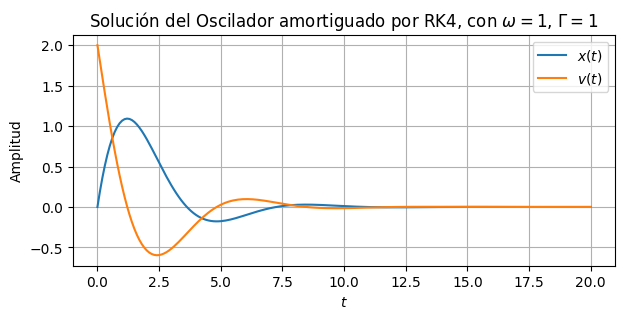

In [ ]:
#-------------- parametros del oscilador --------------
Γ = 1            # Coeficiente de friccion (cumplen: Γ<2ω)
ω = 1            # Frecuencia natural

#-------------- parametros de integracion --------------
dt = 0.1         # tamaño de paso
t0 = 0 ; tf = 20 # intervalo de integracion

t = np.arange(t0, tf+dt, dt) # arreglo de tiempo
x = np.zeros(len(t))         # arreglo posicion
v = np.zeros(len(t))         # arreglo velocidad
x[0] = 0 ; v[0] = 2          # condiciones iniciales
y = [x[0],v[0]]              # [pos, vel] iniciales entrantes a rk4


for i in tqdm(range(len(t)-1)):
  y = RK4( function, y, t[i] , dt)  # RK4; func=SED acoplado, y=condi iniciales
  x[i+1] = y[0]                     # guarda pos y vel
  v[i+1] = y[1]


plt.figure(figsize=(7,3))
plt.plot(t, x, label='$x(t)$')
plt.plot(t, v, label='$v(t)$')
plt.title('Solución del Oscilador amortiguado por RK4, con $\omega=%s$, $\Gamma=%s$'%(ω,Γ))
plt.xlabel('$t$')
plt.ylabel('Amplitud')
plt.grid()
plt.legend()

## **4. Espacio Fásico**

Soluciones para 200 condiciones iniciales aleatorias, con los siguientes casos: <br>

caso 1: **Armónico** (cumple: $Γ=0$) <br>
> Γ = 0    Coef fricción <br>
> ω = 1    Frecuencia natural <br>

caso 2: **Amortiguado** (cumple: $Γ<2ω$)  <br>
> Γ = 1    Coef fricción <br>
> ω = 1    Frecuencia natural <br>


caso 3: **Amortiguamiento critico** (cumple: $Γ=2ω$) <br>
> Γ = 1    Coef fricción <br>
> ω = 1/2    Frecuencia natural <br>


caso 4: **Sobreamortiguado** (cumple: $Γ>2ω$) <br>
> Γ = 2    Coef fricción <br>
> ω = 1/2    Frecuencia natural <br>


100%|██████████| 200/200 [00:02<00:00, 75.39it/s]


Text(0.5, 0, '$x(t)$')

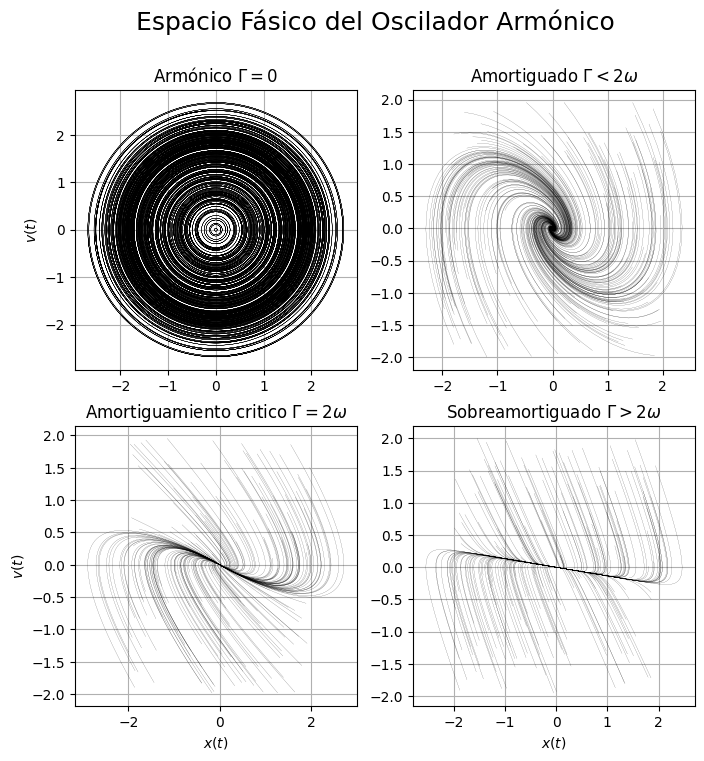

In [ ]:
# lista de parametros del oscilador
Γ_list = [0, 1, 1, 2]
ω_list = [1, 1, 1/2, 1/2]

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8,8)) # figura 2x2
indx_f = [0, 0, 1, 1] # indices filas (para subplots)
indx_c = [0, 1, 0, 1] # indices columnas

for j in range(len(ω_list )): # para los 4 casos del oscilador
    Γ = Γ_list[j]
    ω = ω_list[j]

    #-------------- parametros de integracion --------------
    dt = 0.1                         # tamaño de paso
    t0 = 0 ; tf = 40                 # intervalo de integracion
    t = np.arange(t0, tf+dt, dt)     # arreglo de tiempo
    x = np.zeros(len(t))             # arreglo posicion
    v = np.zeros(len(t))             # arreglo velocidad

    Ns = 200                         # numero de condiciones iniciales
    x0s = np.random.uniform(-2,2,Ns) # condiciones iniciales aleatorias
    v0s = np.random.uniform(-2,2,Ns)

    for n in tqdm(range(Ns)):        # para cada condicion inicial
      x[0] = x0s[n]
      v[0] = v0s[n]
      y = [x[0],v[0]]
      for i in range(len(t)-1):     # RK4:  func=SED acoplado, y=condi iniciales
          y = RK4( function, y, t[i], dt)
          x[i+1] = y[0]             # guarda pos y vel
          v[i+1] = y[1]

      axs[indx_f[j], indx_c[j]].plot(x, v, color='black', lw=0.1) # cada sublplot
    axs[indx_f[j], indx_c[j]].grid()


fig.suptitle('Espacio Fásico del Oscilador Armónico', fontsize=18)
axs[0,0].set_title('Armónico $Γ=0$')
axs[0,1].set_title('Amortiguado $Γ<2ω$')
axs[1,0].set_title('Amortiguamiento critico $Γ=2ω$')
axs[1,1].set_title('Sobreamortiguado $Γ>2ω$')

axs[0,0].set_ylabel('$v(t)$')
axs[1,0].set_ylabel('$v(t)$')
axs[1,0].set_xlabel('$x(t)$')
axs[1,1].set_xlabel('$x(t)$')

## **5. Análisis físico** <br>

<p align="justify"> En el primer caso, el oscilador armónico, con $Γ=0$, el espacio fásico son circunferencias debido a que las soluciones a la ecuación diferencial para la posición son funciones armónicas senos y cosenos, y como la velocidad es la derivada de la posición, la gráfica posición vs velocidad resulta una circunferencia como la observada. </p>

<p align="justify"> En general se puede observar cómo se pierde la tendencia de circunferencia a medida que va de armónico a amortiguado, a amortiguamiento crítico, y finalmente a sobreamortiguado; pues en estas últimas aparece el factor de la solución exponencial decreciente, el cual va limitando y acotando cada vez más la amplitud y consecuentemente la periodicidad de las funciones armónicas, obligándolas a aproximarse al valor cero, y causando que de la tendencia circular se pase a una tendencia espiral con atractor en el origen (0,0). </p>

<p align="justify"> Esta espiral se va achatando cada vez más a medida que el factor de amortiguación aumenta, llegando prácticamente a volver la espiral plana en el caso sobreamortiguado </p>

<p align="center">
<img src=https://i.postimg.cc/hPcXPtYh/oscilador.png width="600">
<br>
<font size=2>Fig1. Solucion del oscilador </p> <br>








In [ ]:
#Tarea 5: 100/100
#1. 20/20
#  Primer orden 20/20

#2. 20/20
#  RK2 20/20

#3. 20/20
#  Amortiguado 20/20

#4. 20/20
#  Espacios de Fase
#  Armónico                  5/5
#  Amortiguado               5/5
#  Amortiguamiento crítico   5/5
#  Sobreamortiguado          5/5

#5. 20/20
#  Analisis Físico 20/20